<a href="https://colab.research.google.com/github/donesait/toxic-text-classification/blob/main/toxic_text_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Исследовательский анализ данных

Импорт библиотек

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

Загрузка и разбор датасета

In [ ]:
data_list = []
with open("./sample_data/dataset.txt") as file:
    for line in file:
        labels = line.split()[0]
        text = line[len(labels)+1:].strip()
        labels = labels.split(",")
        mask = [1 if "__label__NORMAL" in labels else 0,
                1 if "__label__INSULT" in labels else 0,
                1 if "__label__THREAT" in labels else 0,
                1 if "__label__OBSCENITY" in labels else 0]
        data_list.append((text, *mask))

In [ ]:
df = pd.DataFrame(data_list, columns=["text", "normal", "insult", "threat", "obscenity"])

In [ ]:
df

,text,normal,insult,threat,obscenity
0,скотина! что сказать,0,1,0,0
1,я сегодня проезжала по рабочей и между домами ...,1,0,0,0
2,очередной лохотрон. зачем придумывать очередно...,1,0,0,0
3,"ретро дежавю ... сложно понять чужое сердце , ...",1,0,0,0
4,а когда мы статус агрогородка получили?,1,0,0,0
...,...,...,...,...,...
248285,правильно всё по пять (5)...,1,0,0,0
248286,ёбанные нубы заходите на сервер мой ник _creep...,0,1,0,0
248287,а у меня наверное рекорд в 1962 году в училище...,1,0,0,0
248288,спасибо всем большое),1,0,0,0


Базовая информация

In [ ]:
print("Пример данных:")
print(df.head())
print("\nИнформация:")
print(df.info())
print("\nРаспределение по меткам:")
print(df[["normal", "insult", "threat", "obscenity"]].sum())

Пример данных:
                                                text  normal  insult  threat  \
0                               скотина! что сказать       0       1       0   
1  я сегодня проезжала по рабочей и между домами ...       1       0       0   
2  очередной лохотрон. зачем придумывать очередно...       1       0       0   
3  ретро дежавю ... сложно понять чужое сердце , ...       1       0       0   
4            а когда мы статус агрогородка получили?       1       0       0   

   obscenity  
0          0  
1          0  
2          0  
3          0  
4          0  

Информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248290 entries, 0 to 248289
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   text       248290 non-null  object
 1   normal     248290 non-null  int64 
 2   insult     248290 non-null  int64 
 3   threat     248290 non-null  int64 
 4   obscenity  248290 non-null  int64 
dtypes: int

Уровень токсичности — сумма меток INSULT, THREAT, OBSCENITY

In [ ]:
df["toxicity_level"] = df[["insult", "threat", "obscenity"]].sum(axis=1)

Очистка текста

In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)  # ссылки
    text = re.sub(r"[^а-яa-z0-9\s]", "", text)  # только буквы и цифры
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)

Базовая информация

In [ ]:
print("Пример данных:")
print(df.head())

print("\nИнформация:")
print(df.info())

print("\nРаспределение по меткам:")
print(df[["normal", "insult", "threat", "obscenity"]].sum())

Пример данных:
                                                text  normal  insult  threat  \
0                               скотина! что сказать       0       1       0   
1  я сегодня проезжала по рабочей и между домами ...       1       0       0   
2  очередной лохотрон. зачем придумывать очередно...       1       0       0   
3  ретро дежавю ... сложно понять чужое сердце , ...       1       0       0   
4            а когда мы статус агрогородка получили?       1       0       0   

   obscenity  toxicity_level  \
0          0               1   
1          0               0   
2          0               0   
3          0               0   
4          0               0   

                                          clean_text  
0                                скотина что сказать  
1  я сегодня проезжала по рабочей и между домами ...  
2  очередной лохотрон зачем придумывать очередной...  
3  ретро дежавю сложно понять чужое сердце лиш ощ...  
4             а когда мы статус агро

Распределение классов

<ipython-input-25-2aecedc57a37>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")


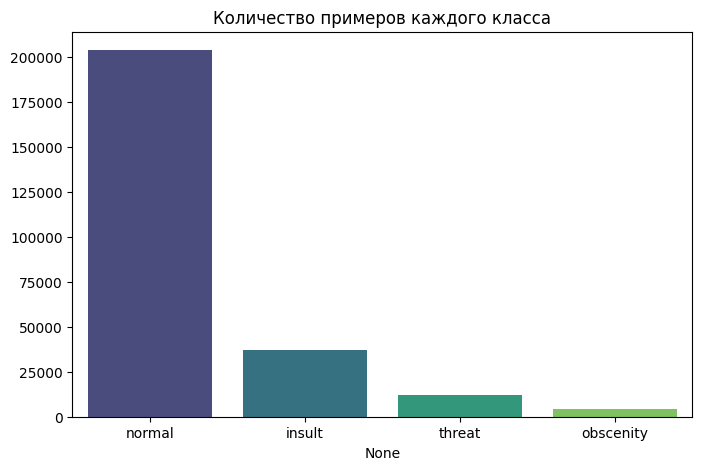

In [ ]:
label_counts = df[["normal", "insult", "threat", "obscenity"]].sum()
plt.figure(figsize=(8, 5))
sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")
plt.title("Количество примеров каждого класса")
plt.show()

Длина текста

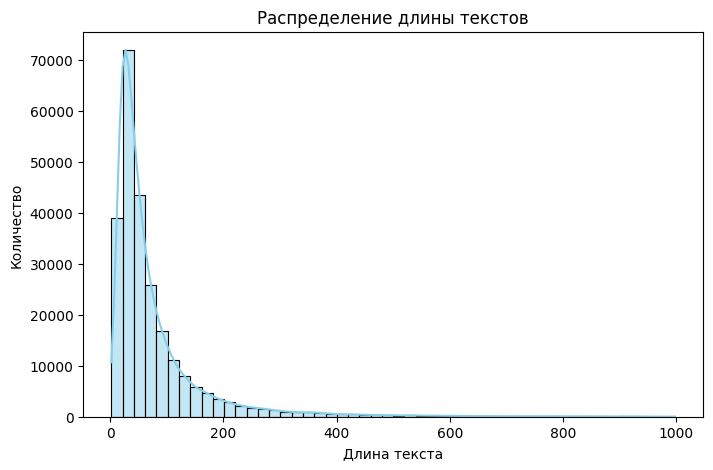

In [ ]:
df["text_length"] = df["text"].apply(len)
plt.figure(figsize=(8, 5))
sns.histplot(df["text_length"], bins=50, kde=True, color='skyblue')
plt.title("Распределение длины текстов")
plt.xlabel("Длина текста")
plt.ylabel("Количество")
plt.show()

Корреляция между метками

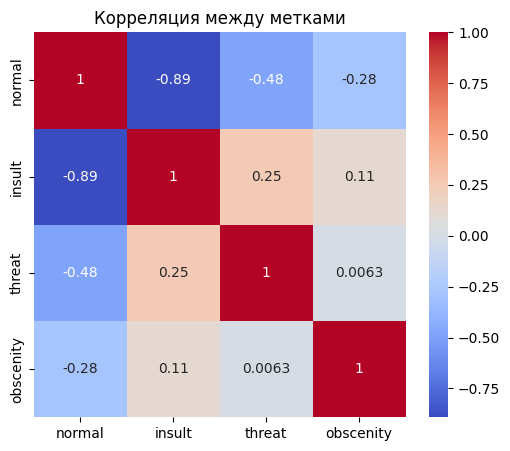

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[["normal", "insult", "threat", "obscenity"]].corr(), annot=True, cmap="coolwarm")
plt.title("Корреляция между метками")
plt.show()

WordCloud по меткам

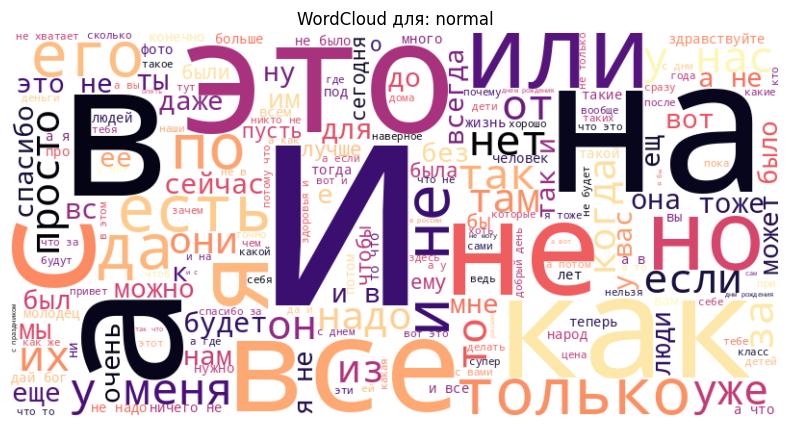

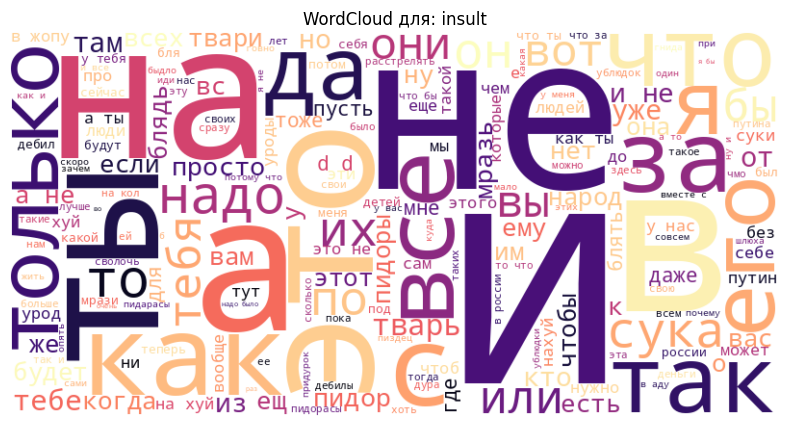

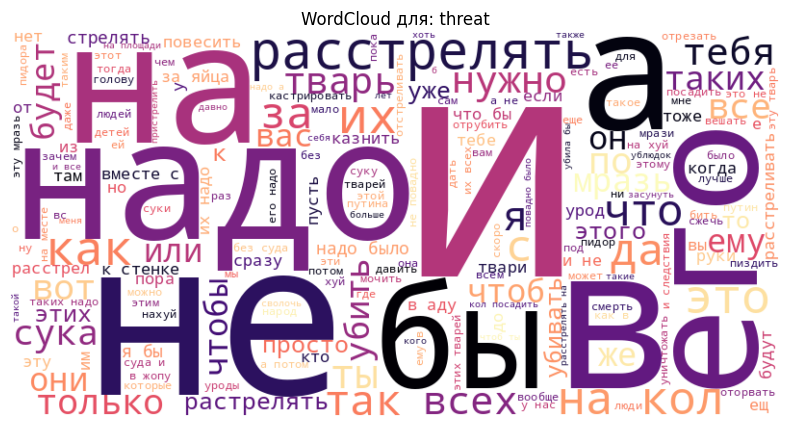

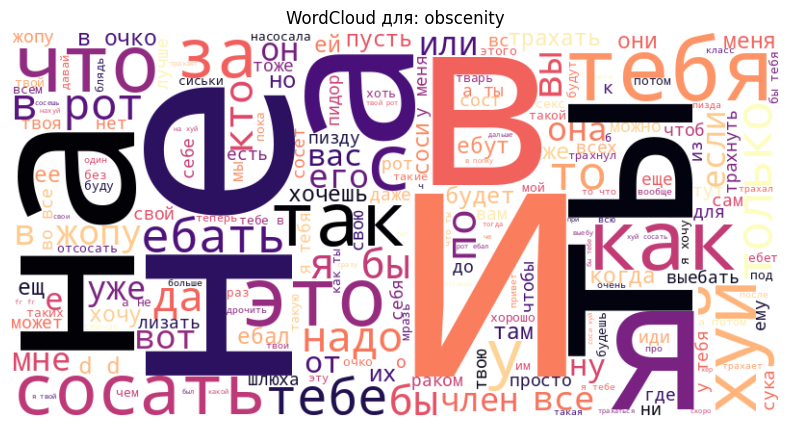

In [ ]:
def plot_wordcloud(df, label, title):
    text = " ".join(df[df[label] == 1]["clean_text"])
    wc = WordCloud(width=800, height=400, background_color="white", colormap="magma").generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

for label in ["normal", "insult", "threat", "obscenity"]:
    plot_wordcloud(df, label, f"WordCloud для: {label}")

WordCloud по уровню токсичности

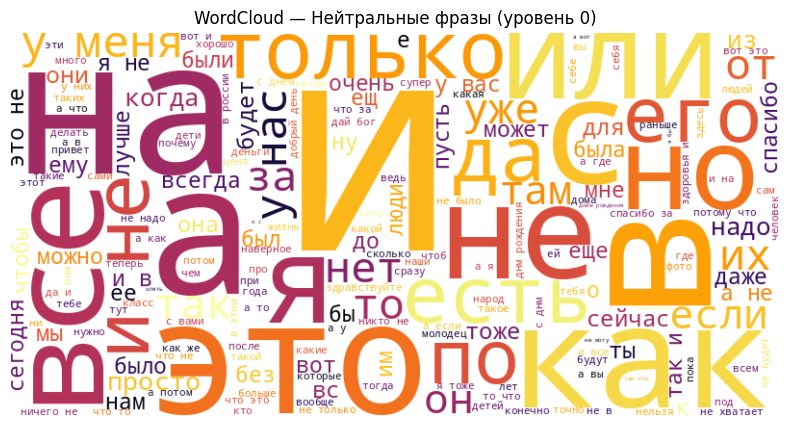

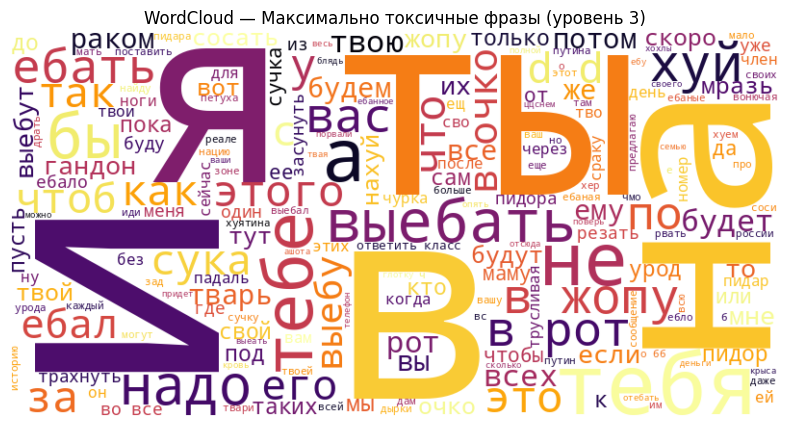

In [ ]:
def plot_wordcloud_by_toxicity(level, title):
    text = " ".join(df[df["toxicity_level"] == level]["clean_text"])
    wc = WordCloud(width=800, height=400, background_color="white", colormap="inferno").generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

plot_wordcloud_by_toxicity(0, "WordCloud — Нейтральные фразы (уровень 0)")
plot_wordcloud_by_toxicity(3, "WordCloud — Максимально токсичные фразы (уровень 3)")

Примеры фраз

In [ ]:
print("\nПримеры самых токсичных фраз:")
print(df[df["toxicity_level"] == 3]["text"].sample(5, random_state=42), "\n")

print("Примеры нейтральных фраз:")
print(df[df["toxicity_level"] == 0]["text"].sample(5, random_state=42))


Примеры самых токсичных фраз:
25101     сколько можно дрочить на этого алконавта? или ...
72590     гондона в очко трахнуть и голого на трассе к с...
192903    ебнись об стену урод, и убейся лучше сам !!! т...
52911     ватоскот ебливый опущеный ради того чтоб у пут...
110335    выебать пидараса на самой высой горе,посадить ...
Name: text, dtype: object 

Примеры нейтральных фраз:
106030    почему вчера было так хорошо и почему сегодня ...
85531                              они плохо учили историю.
240329              17/39 ужастное,позор тому кто ставил!!!
147203                  толку то, приехал чай попил и уехал
245280    q с о в з о в и ваз zтто ле стнии грежим комме...
Name: text, dtype: object


Распределение уровня токсичности

<ipython-input-31-c4244c3272bf>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="toxicity_level", data=df, palette="rocket")


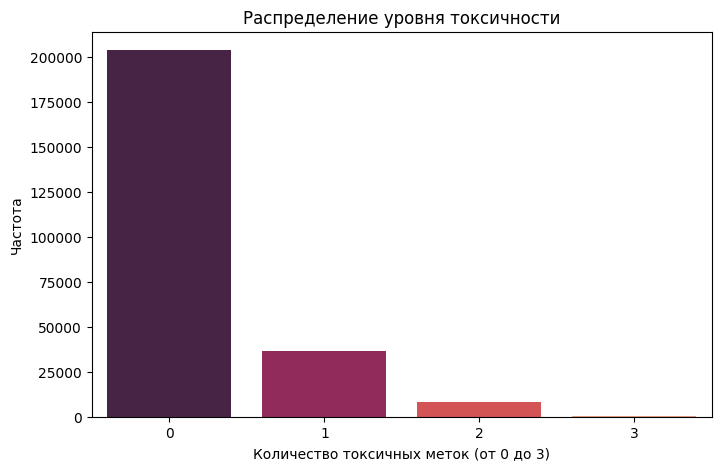

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x="toxicity_level", data=df, palette="rocket")
plt.title("Распределение уровня токсичности")
plt.xlabel("Количество токсичных меток (от 0 до 3)")
plt.ylabel("Частота")
plt.show()

Статистика токсичности

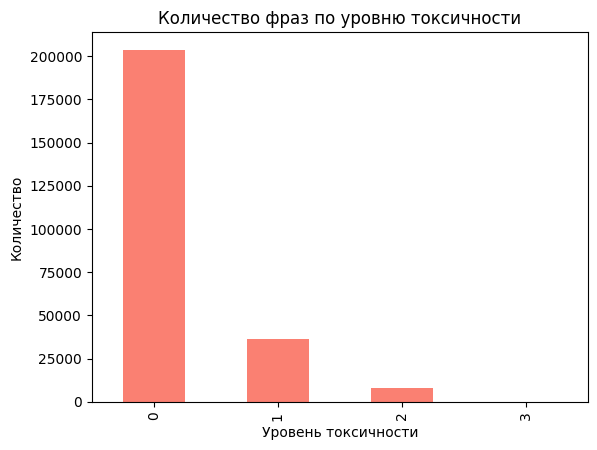


Средний уровень токсичности в датасете: 0.21


In [ ]:
tox_stats = df["toxicity_level"].value_counts().sort_index()
tox_stats.plot(kind="bar", color="salmon")
plt.title("Количество фраз по уровню токсичности")
plt.xlabel("Уровень токсичности")
plt.ylabel("Количество")
plt.show()

print("\nСредний уровень токсичности в датасете:", round(df["toxicity_level"].mean(), 2))

Разделение и векторизация

In [ ]:
X = df["clean_text"]
y = df[["normal", "insult", "threat", "obscenity"]]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("\nРазмерность TF-IDF матрицы:", X_train_tfidf.shape)



Размерность TF-IDF матрицы: (198632, 10000)
